# Step 5: Equivalent Circuit Model (1RC Thevenin) ⚡

## What is an ECM?

An **Equivalent Circuit Model** represents the battery as a simple electrical circuit:

```
        R0          R1
  ─┤├──/\/\/──┬──/\/\/──┬── V_terminal (+)
              │         │
    OCV(SOC)  │   C1  ═╧═
              │         │
  ────────────┴─────────┴── V_terminal (-)
```

### What each component does:

| Component | What it represents | Physical meaning |
|-----------|-------------------|------------------|
| **OCV(SOC)** | Ideal voltage source | The "true" voltage based on charge level |
| **R0** | Ohmic resistance | Instant voltage drop when current flows (wire + contact resistance) |
| **R1 \|\| C1** | RC pair | Slow polarization effect (charge transfer at electrode surface) |

### The 3 Equations

**Equation 1 — SOC update** (how charge level changes):
$$SOC_{k+1} = SOC_k - \frac{I_k \cdot \Delta t}{Q_{max} \cdot 3600}$$

**Equation 2 — RC voltage update** (how the RC pair evolves):
$$V_{RC,k+1} = V_{RC,k} \cdot e^{-\Delta t / \tau} + R_1 \cdot I_k \cdot (1 - e^{-\Delta t / \tau})$$
where $\tau = R_1 \cdot C_1$ (time constant in seconds)

**Equation 3 — Terminal voltage** (what we measure):
$$V_{terminal} = OCV(SOC) - I \cdot R_0 - V_{RC}$$

### Why this model?
- Simple enough to understand and implement
- Captures the main battery dynamics
- Good enough for BoL SOC estimation at moderate C-rates

## 5.1 Load Our Data and Previous Results

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import get_bol_data
from src.coulomb_counting import coulomb_counting
from src.ocv_soc import extract_ocv_soc_raw, fit_ocv_polynomial, get_ocv_from_soc

# Load data
bol = get_bol_data("../data/nasa_alt/battery00.csv")
current = bol['current_load'].values
time = bol['time_relative'].values
voltage_pack = bol['voltage_load'].values
voltage_cell = voltage_pack / 2.0  # Per-cell voltage (measured)

# Compute capacity, SOC, OCV polynomial
q_max = current.mean() * time[-1] / 3600
soc_ref = coulomb_counting(current, time, q_max)
soc_sorted, ocv_sorted = extract_ocv_soc_raw(voltage_pack, soc_ref)
ocv_poly = fit_ocv_polynomial(soc_sorted, ocv_sorted)

print(f"Data: {len(current)} points, Q_max = {q_max:.3f} Ah")
print(f"OCV polynomial ready (degree 9, RMSE = {np.sqrt(np.mean((ocv_sorted - ocv_poly(soc_sorted))**2))*1000:.1f} mV)")

Data: 3674 points, Q_max = 2.452 Ah
OCV polynomial ready (degree 9, RMSE = 13.3 mV)


## 5.2 Understand Each Equation with Code

Let's implement each equation one at a time, then combine them.

### Equation 1: SOC Update

This is just Coulomb Counting — we already know this!
$$SOC_{k+1} = SOC_k - \frac{I_k \cdot \Delta t}{Q_{max} \cdot 3600}$$

In [2]:
# Equation 1: SOC update (one step)
soc_now = 1.0       # Current SOC (100%)
I = 2.5              # Current (Amps)
dt = 1.0             # Time step (1 second)

soc_next = soc_now - (I * dt) / (q_max * 3600)

print("Equation 1: SOC Update")
print(f"  SOC_now = {soc_now*100:.4f}%")
print(f"  After 1 second of {I}A discharge:")
print(f"  SOC_next = {soc_next*100:.4f}%")
print(f"  SOC dropped by {(soc_now - soc_next)*100:.4f}%")
print(f"\n  That's about {1/(soc_now - soc_next):.0f} seconds to drain 1% SOC")

Equation 1: SOC Update
  SOC_now = 100.0000%
  After 1 second of 2.5A discharge:
  SOC_next = 99.9717%
  SOC dropped by 0.0283%

  That's about 3531 seconds to drain 1% SOC


### Equation 2: RC Voltage Update

This is the new part. The RC pair creates a voltage that **builds up slowly** during discharge and **decays slowly** when current stops.

$$V_{RC,k+1} = V_{RC,k} \cdot e^{-\Delta t / \tau} + R_1 \cdot I_k \cdot (1 - e^{-\Delta t / \tau})$$

Think of it like a sponge:
- **During discharge:** The sponge absorbs water (V_RC increases toward R1×I)
- **During rest:** The sponge slowly releases water (V_RC decays toward 0)
- **τ = R1×C1** controls how fast this happens (larger τ = slower)

R1 = 20 mΩ, C1 = 3000 F, tau = R1×C1 = 60 s
Steady-state V_RC = R1 × I = 50.0 mV


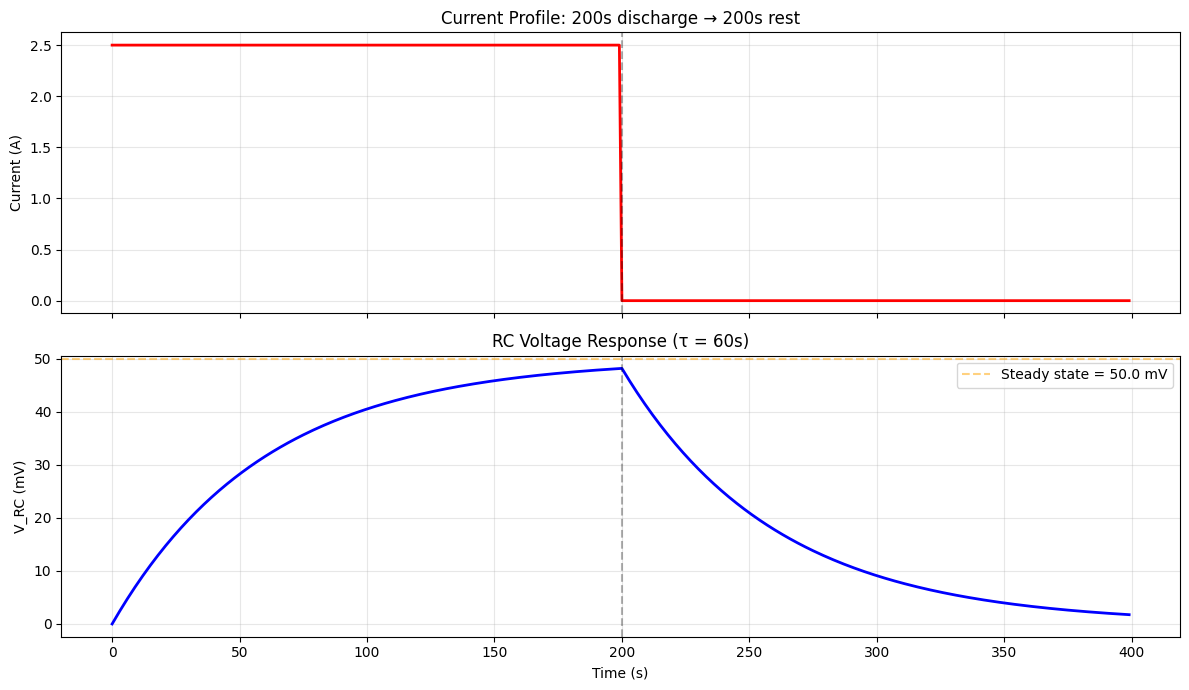


During discharge: V_RC builds up toward 50.0 mV (takes ~3τ = 180s)
During rest: V_RC decays back toward 0 mV


In [3]:
# Equation 2: RC voltage — let's visualize how it behaves

# Pick some example parameters
R1 = 0.02       # 20 mΩ
C1 = 3000        # 3000 F
tau = R1 * C1    # Time constant = 60 seconds
I = 2.5          # Current

print(f"R1 = {R1*1000:.0f} mΩ, C1 = {C1:.0f} F, tau = R1×C1 = {tau:.0f} s")
print(f"Steady-state V_RC = R1 × I = {R1*I*1000:.1f} mV")

# Simulate V_RC during 200s of discharge, then 200s of rest
t_total = np.arange(0, 400, 1.0)  # 400 seconds
v_rc = np.zeros(len(t_total))
I_profile = np.zeros(len(t_total))
I_profile[:200] = 2.5   # Discharge for first 200s
I_profile[200:] = 0.0   # Rest for last 200s

for k in range(1, len(t_total)):
    dt = 1.0
    exp_term = np.exp(-dt / tau)
    v_rc[k] = v_rc[k-1] * exp_term + R1 * I_profile[k-1] * (1 - exp_term)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(t_total, I_profile, 'r-', linewidth=2)
ax1.set_ylabel('Current (A)')
ax1.set_title('Current Profile: 200s discharge → 200s rest')
ax1.grid(True, alpha=0.3)
ax1.axvline(x=200, color='k', linestyle='--', alpha=0.3)

ax2.plot(t_total, v_rc * 1000, 'b-', linewidth=2)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('V_RC (mV)')
ax2.set_title(f'RC Voltage Response (τ = {tau:.0f}s)')
ax2.grid(True, alpha=0.3)
ax2.axvline(x=200, color='k', linestyle='--', alpha=0.3)
ax2.axhline(y=R1*2.5*1000, color='orange', linestyle='--', alpha=0.5, label=f'Steady state = {R1*2.5*1000:.1f} mV')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nDuring discharge: V_RC builds up toward {R1*I*1000:.1f} mV (takes ~3τ = {3*tau:.0f}s)")
print(f"During rest: V_RC decays back toward 0 mV")

### Equation 3: Terminal Voltage

The voltage you actually measure:
$$V_{terminal} = OCV(SOC) - I \cdot R_0 - V_{RC}$$

- **OCV(SOC)**: The "ideal" voltage → from our polynomial
- **I × R0**: The instant voltage drop → appears/disappears immediately
- **V_RC**: The slow voltage drop → builds up/decays exponentially

In [4]:
# Equation 3: Let's compute terminal voltage at one instant
# Suppose: SOC=80%, I=2.5A, R0=15mΩ, V_RC has built up to 30mV

soc_now = 0.80
I = 2.5        # Amps (discharge current, positive)
R0 = 0.015     # 15 milliohms
V_RC = 0.030   # 30 millivolts (built up over time)

ocv_now = get_ocv_from_soc(soc_now, ocv_poly)
v_R0 = I * R0            # instant drop
v_terminal = ocv_now - v_R0 - V_RC

print(f"At SOC = {soc_now*100:.0f}%:")
print(f"  OCV(SOC)      = {ocv_now:.4f} V")
print(f"  I × R0        = {v_R0*1000:.1f} mV  (instant drop)")
print(f"  V_RC           = {V_RC*1000:.1f} mV  (slow drop)")
print(f"  V_terminal     = {v_terminal:.4f} V")
print(f"  Total drop     = {(v_R0 + V_RC)*1000:.1f} mV")

At SOC = 80%:
  OCV(SOC)      = 3.9210 V
  I × R0        = 37.5 mV  (instant drop)
  V_RC           = 30.0 mV  (slow drop)
  V_terminal     = 3.8535 V
  Total drop     = 67.5 mV


## 5.3 Full ECM Simulation — Putting It All Together

Now the big moment! We loop through every time step and apply **all 3 equations** together:

```
For each time step k:
    1. Update SOC          → SOC[k] = SOC[k-1] - (I[k] × dt) / (Q_max × 3600)
    2. Update V_RC         → V_RC[k] = V_RC[k-1] × exp(-dt/τ) + R1 × I[k] × (1 - exp(-dt/τ))
    3. Compute V_terminal  → V[k] = OCV(SOC[k]) - I[k] × R0 - V_RC[k]
```

We'll use **guessed** parameters for now (we'll optimize them in Step 6):
- R0 = 30 mΩ (instant resistance)
- R1 = 20 mΩ (RC resistance)
- C1 = 5000 F (RC capacitance → τ = R1×C1 = 100s)

In [6]:
# ──── Parameters (guessed for now) ────
R0 = 0.030    # 30 mΩ
R1 = 0.020    # 20 mΩ
C1 = 5000.0   # 5000 F  →  τ = R1*C1 = 100 s
tau = R1 * C1  # time constant

# ──── Data from earlier cells (already loaded) ────
time_s = time               # from cell 3
voltage_measured = voltage_cell  # per-cell measured voltage

dt_arr = np.diff(time_s, prepend=time_s[0])  # time step array
N = len(time_s)

# ──── Initialize arrays ────
soc_sim   = np.zeros(N)
v_rc_sim  = np.zeros(N)
v_sim     = np.zeros(N)

soc_sim[0] = 1.0      # Start fully charged
v_rc_sim[0] = 0.0     # No polarization at start
v_sim[0] = get_ocv_from_soc(soc_sim[0], ocv_poly) - current[0] * R0

# ──── Simulation loop ────
for k in range(1, N):
    dt = dt_arr[k]
    I = current[k]
    
    # Equation 1: SOC update
    soc_sim[k] = soc_sim[k-1] - (I * dt) / (q_max * 3600)
    
    # Equation 2: V_RC update
    exp_term = np.exp(-dt / tau)
    v_rc_sim[k] = v_rc_sim[k-1] * exp_term + R1 * I * (1 - exp_term)
    
    # Equation 3: Terminal voltage
    ocv_k = get_ocv_from_soc(soc_sim[k], ocv_poly)
    v_sim[k] = ocv_k - I * R0 - v_rc_sim[k]

print(f"Simulation complete: {N} time steps")
print(f"SOC: {soc_sim[0]*100:.1f}% → {soc_sim[-1]*100:.1f}%")
print(f"V_sim:  {v_sim[0]:.4f} → {v_sim[-1]:.4f} V")
print(f"V_meas: {voltage_measured[0]:.4f} → {voltage_measured[-1]:.4f} V")

Simulation complete: 3674 time steps
SOC: 100.0% → -0.0%
V_sim:  4.1633 → 2.4393 V
V_meas: -0.0130 → 2.4070 V


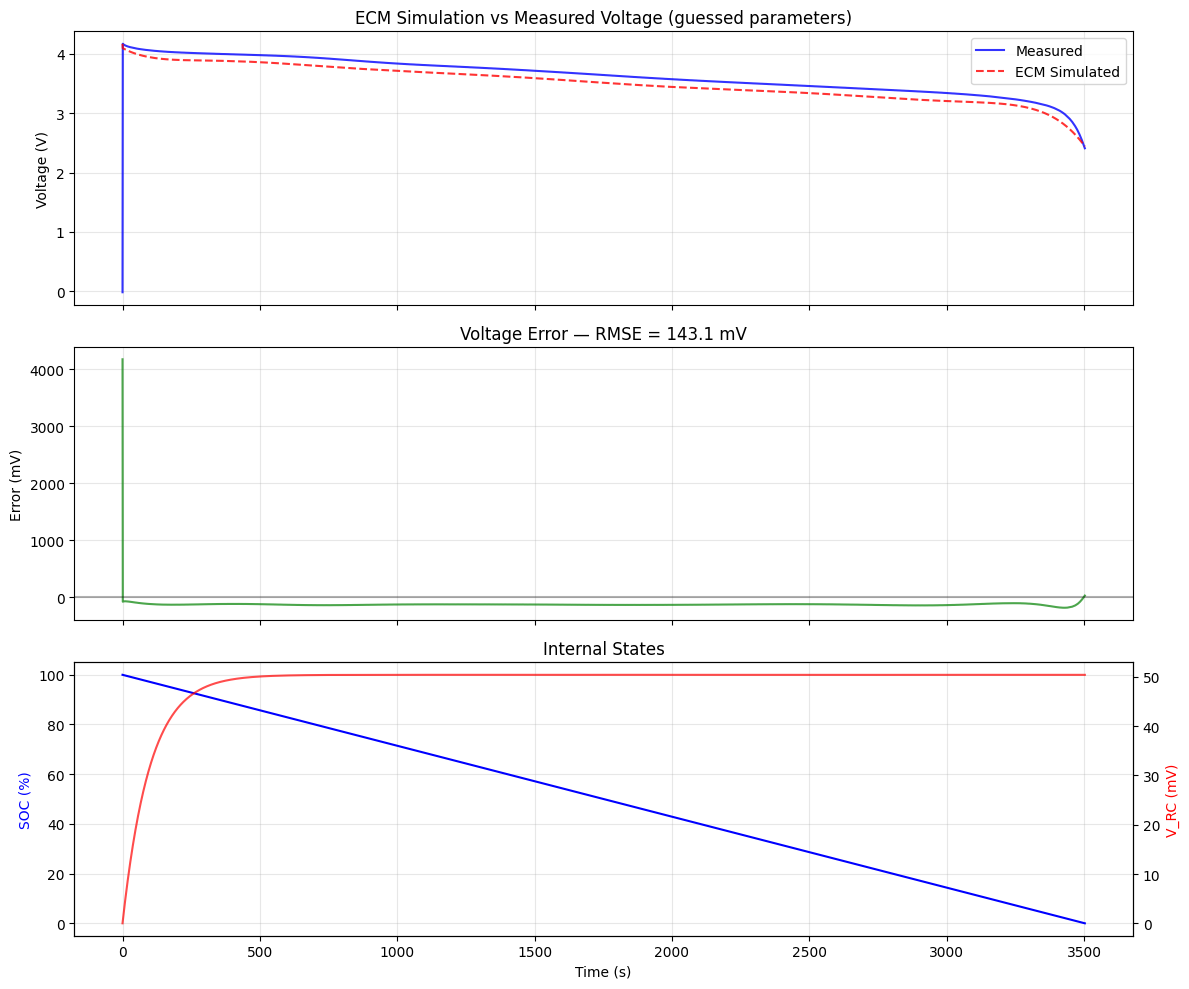


With guessed parameters: RMSE = 143.1 mV
→ This will improve a LOT after parameter optimization in Step 6!


In [7]:
# ──── Plot: Simulated vs Measured Voltage ────
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: Voltage comparison
axes[0].plot(time_s, voltage_measured, 'b-', label='Measured', alpha=0.8)
axes[0].plot(time_s, v_sim, 'r--', label='ECM Simulated', alpha=0.8)
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title('ECM Simulation vs Measured Voltage (guessed parameters)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Voltage error
error = v_sim - voltage_measured
rmse = np.sqrt(np.mean(error**2))
axes[1].plot(time_s, error * 1000, 'g-', alpha=0.7)  # in mV
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[1].set_ylabel('Error (mV)')
axes[1].set_title(f'Voltage Error — RMSE = {rmse*1000:.1f} mV')
axes[1].grid(True, alpha=0.3)

# Panel 3: SOC + V_RC
ax3a = axes[2]
ax3b = ax3a.twinx()
ax3a.plot(time_s, soc_sim * 100, 'b-', label='SOC')
ax3b.plot(time_s, v_rc_sim * 1000, 'r-', label='V_RC', alpha=0.7)
ax3a.set_xlabel('Time (s)')
ax3a.set_ylabel('SOC (%)', color='b')
ax3b.set_ylabel('V_RC (mV)', color='r')
ax3a.set_title('Internal States')
ax3a.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/ecm_simulation_guess.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nWith guessed parameters: RMSE = {rmse*1000:.1f} mV")
print("→ This will improve a LOT after parameter optimization in Step 6!")

## 5.4 Reusable `simulate_ecm` Function

Before exploring sensitivity, let's wrap our 3-equation loop into a **clean, reusable function**.

This is exactly the function that will go into `src/ecm_model.py` later!

```
simulate_ecm(current, time_s, q_max, ocv_poly, R0, R1, C1)
    → returns: soc, v_rc, v_terminal
```

**Why a function?** So we can easily call it with different R0/R1/C1 values and compare results.

In [9]:
def simulate_ecm(current, time_s, q_max, ocv_poly, R0, R1, C1):
    """
    Run a full 1RC ECM simulation.
    
    Inputs:
        current   : array of current values (A), positive = discharge
        time_s    : array of time values (s)
        q_max     : battery capacity (Ah)
        ocv_poly  : OCV polynomial (from numpy)
        R0        : ohmic resistance (Ω)
        R1        : RC resistance (Ω)
        C1        : RC capacitance (F)
    
    Returns:
        soc       : SOC array
        v_rc      : RC voltage array (V)
        v_term    : terminal voltage array (V)
    """
    tau = R1 * C1
    dt_arr = np.diff(time_s, prepend=time_s[0])
    N = len(time_s)
    
    soc = np.zeros(N)
    v_rc = np.zeros(N)
    v_term = np.zeros(N)
    
    soc[0] = 1.0
    v_rc[0] = 0.0
    v_term[0] = get_ocv_from_soc(soc[0], ocv_poly) - current[0] * R0
    
    for k in range(1, N):
        dt = dt_arr[k]
        I = current[k]
        soc[k] = soc[k-1] - (I * dt) / (q_max * 3600)
        exp_t = np.exp(-dt / tau)
        v_rc[k] = v_rc[k-1] * exp_t + R1 * I * (1 - exp_t)
        v_term[k] = get_ocv_from_soc(soc[k], ocv_poly) - I * R0 - v_rc[k]
    
    return soc, v_rc, v_term

# Quick test with our guessed parameters
soc_test, vrc_test, v_test = simulate_ecm(current, time_s, q_max, ocv_poly, 0.030, 0.020, 5000)
rmse_test = np.sqrt(np.mean((v_test - voltage_measured)**2)) * 1000
print(f"simulate_ecm() works! RMSE = {rmse_test:.1f} mV (same as before)")
print(f"Now we can call it with ANY parameters easily.")

simulate_ecm() works! RMSE = 143.1 mV (same as before)
Now we can call it with ANY parameters easily.


## 5.5 Parameter Sensitivity — What Does Each Parameter Do?

Now that we have `simulate_ecm()`, let's see how each parameter affects the voltage curve:

| Parameter | What happens when you **increase** it? |
|-----------|---------------------------------------|
| **R0** | Entire curve shifts **down** (bigger instant drop) |
| **R1** | More voltage **sag** (bigger slow drop) |
| **τ = R1×C1** | Sag builds up **slower** (more spread out) |

Let's visualize this!

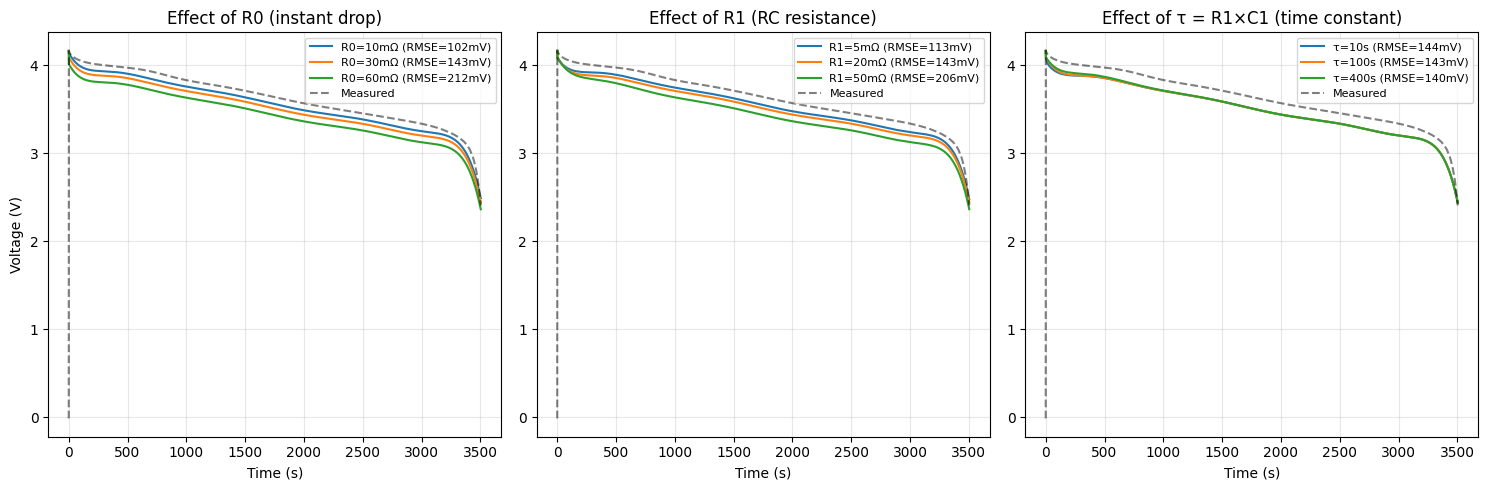


Key takeaways:
  R0 → shifts the ENTIRE curve up/down (instant offset)
  R1 → affects the slow voltage sag amount
  τ  → affects how fast the slow sag builds up


In [10]:
# ──── Parameter Sensitivity Plots ────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Vary R0 (keep R1=20mΩ, C1=5000F fixed) ──
for r0_val in [0.010, 0.030, 0.060]:
    _, _, v = simulate_ecm(current, time_s, q_max, ocv_poly, r0_val, 0.020, 5000)
    rmse_val = np.sqrt(np.mean((v - voltage_measured)**2)) * 1000
    axes[0].plot(time_s, v, label=f'R0={r0_val*1000:.0f}mΩ (RMSE={rmse_val:.0f}mV)')
axes[0].plot(time_s, voltage_measured, 'k--', alpha=0.5, label='Measured')
axes[0].set_title('Effect of R0 (instant drop)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Voltage (V)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# ── Vary R1 (keep R0=30mΩ, C1=5000F fixed) ──
for r1_val in [0.005, 0.020, 0.050]:
    _, _, v = simulate_ecm(current, time_s, q_max, ocv_poly, 0.030, r1_val, 5000)
    rmse_val = np.sqrt(np.mean((v - voltage_measured)**2)) * 1000
    axes[1].plot(time_s, v, label=f'R1={r1_val*1000:.0f}mΩ (RMSE={rmse_val:.0f}mV)')
axes[1].plot(time_s, voltage_measured, 'k--', alpha=0.5, label='Measured')
axes[1].set_title('Effect of R1 (RC resistance)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# ── Vary τ via C1 (keep R0=30mΩ, R1=20mΩ fixed) ──
for c1_val in [500, 5000, 20000]:
    tau_val = 0.020 * c1_val
    _, _, v = simulate_ecm(current, time_s, q_max, ocv_poly, 0.030, 0.020, c1_val)
    rmse_val = np.sqrt(np.mean((v - voltage_measured)**2)) * 1000
    axes[2].plot(time_s, v, label=f'τ={tau_val:.0f}s (RMSE={rmse_val:.0f}mV)')
axes[2].plot(time_s, voltage_measured, 'k--', alpha=0.5, label='Measured')
axes[2].set_title('Effect of τ = R1×C1 (time constant)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/ecm_param_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey takeaways:")
print("  R0 → shifts the ENTIRE curve up/down (instant offset)")
print("  R1 → affects the slow voltage sag amount")
print("  τ  → affects how fast the slow sag builds up")

## 5.6 Summary — What We Learned

### The 1RC Thevenin ECM has:
| What | Symbol | Meaning |
|------|--------|---------|
| **State 1** | SOC | Battery charge level (0–100%) |
| **State 2** | V_RC | Polarization voltage (slow dynamics) |
| **Parameter 1** | R0 | Instant resistance (ohmic drop) |
| **Parameter 2** | R1 | RC resistance (diffusion/charge-transfer) |
| **Parameter 3** | C1 | RC capacitance (how slow the dynamics are) |

### Three equations update every time step:
1. **SOC** ← previous SOC minus charge used
2. **V_RC** ← exponential decay + new contribution  
3. **V_terminal** ← OCV(SOC) minus both voltage drops

### What's next?
With guessed parameters, the RMSE is high. In **Step 6 (Parameter Identification)**, we'll use `scipy.optimize.minimize` to find the best R0, R1, C1 that minimize the RMSE.

**→ Now let's write the clean `src/ecm_model.py` module!**